1.Load and explore data

In [17]:
import sys
print(sys.executable)

c:\Users\susmi\AppData\Local\Programs\Python\Python314\python.exe


In [18]:
import pandas as pd
import numpy as np

df = pd.read_csv('heart.csv')

print("First 5 rows:")
print(df.head())
print("\nShape:", df.shape)
print("\nInfo:")
df.info()
print("\nStatistics:")
print(df.describe())

First 5 rows:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

Shape: (918, 12)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------

2.clean data

In [19]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Check duplicates
print("\nDuplicates:", df.duplicated().sum())
df = df.drop_duplicates()

print("\nFinal shape:", df.shape)

Missing values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Duplicates: 0

Final shape: (918, 12)


3 corelation checking

In [20]:
# Check correlation with target
df_check = df.copy()

# Encode categorical columns temporarily
from sklearn.preprocessing import LabelEncoder
le_check = LabelEncoder()

for col in df_check.select_dtypes(include=['object']).columns:
    df_check[col] = le_check.fit_transform(df_check[col].astype(str))

# Check correlation
correlation = df_check.corr()['HeartDisease'].sort_values(ascending=False)
print(correlation)

HeartDisease      1.000000
ExerciseAngina    0.494282
Oldpeak           0.403951
Sex               0.305445
Age               0.282039
FastingBS         0.267291
RestingBP         0.107589
RestingECG        0.057384
Cholesterol      -0.232741
ChestPainType    -0.386828
MaxHR            -0.400421
ST_Slope         -0.558771
Name: HeartDisease, dtype: float64


C:\Users\susmi\AppData\Local\Temp\ipykernel_3208\2308208115.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_check.select_dtypes(include=['object']).columns:


4. Seperate features and target

In [21]:
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']  # Already 0 and 1

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

X shape: (918, 11)
y shape: (918,)

Target distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64


5. Split data

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (734, 11)
X_test shape: (184, 11)
y_train shape: (734,)
y_test shape: (184,)


6. Handling missing values

In [23]:
from sklearn.impute import SimpleImputer

# Identify column types
numerical_columns = X_train.select_dtypes(include=['float64', 'int64']).columns
categorical_columns = X_train.select_dtypes(include=['object']).columns

print("Numerical columns:", list(numerical_columns))
print("Categorical columns:", list(categorical_columns))

# Numerical imputer
num_imputer = SimpleImputer(strategy='mean')
X_train[numerical_columns] = num_imputer.fit_transform(X_train[numerical_columns])
X_test[numerical_columns] = num_imputer.transform(X_test[numerical_columns])

# Categorical imputer
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[categorical_columns] = cat_imputer.fit_transform(X_train[categorical_columns])
X_test[categorical_columns] = cat_imputer.transform(X_test[categorical_columns])

print("\nMissing values in train:", X_train.isnull().sum().sum())
print("Missing values in test:", X_test.isnull().sum().sum())

C:\Users\susmi\AppData\Local\Temp\ipykernel_3208\1702748836.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X_train.select_dtypes(include=['object']).columns


Numerical columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

Missing values in train: 0
Missing values in test: 0


7. Encode categorical columns

In [24]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nX_train after encoding:")
print(X_train.head())

Sex: {'F': np.int64(0), 'M': np.int64(1)}
ChestPainType: {'ASY': np.int64(0), 'ATA': np.int64(1), 'NAP': np.int64(2), 'TA': np.int64(3)}
RestingECG: {'LVH': np.int64(0), 'Normal': np.int64(1), 'ST': np.int64(2)}
ExerciseAngina: {'N': np.int64(0), 'Y': np.int64(1)}
ST_Slope: {'Down': np.int64(0), 'Flat': np.int64(1), 'Up': np.int64(2)}

X_train after encoding:
      Age  Sex  ChestPainType  RestingBP  Cholesterol  FastingBS  RestingECG  \
795  42.0    1              2      120.0        240.0        1.0           1   
25   36.0    1              2      130.0        209.0        0.0           1   
84   56.0    1              0      150.0        213.0        1.0           1   
10   37.0    0              2      130.0        211.0        0.0           1   
344  51.0    1              0      120.0          0.0        1.0           1   

     MaxHR  ExerciseAngina  Oldpeak  ST_Slope  
795  194.0               0      0.8         0  
25   178.0               0      0.0         2  
84   125.0   

8. Scale Numerical columns

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

print("X_train after scaling:")
print(X_train.head())

X_train after scaling:
          Age  Sex  ChestPainType  RestingBP  Cholesterol  FastingBS  \
795 -1.245067    1              2  -0.708985     0.372803   1.842609   
25  -1.886236    1              2  -0.166285     0.086146  -0.542709   
84   0.250993    1              0   0.919115     0.123134   1.842609   
10  -1.779375    0              2  -0.166285     0.104640  -0.542709   
344 -0.283314    1              0  -0.708985    -1.846478   1.842609   

     RestingECG     MaxHR  ExerciseAngina   Oldpeak  ST_Slope  
795           1  2.284353               0 -0.097061         0  
25            1  1.652241               0 -0.836286         2  
84            1 -0.441628               1  0.087745         1  
10            1  0.229991               0 -0.836286         2  
344           1 -1.271274               0 -0.836286         1  


9. Fix imbalance with SMOTE

In [26]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_balanced))

Before SMOTE: [333 401]
After SMOTE: [401 401]


10. Train model

In [27]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train_balanced, y_train_balanced)
print("Model training complete! ✅")

Model training complete! ✅


11. Evaluate model

Accuracy: 0.875
ROC-AUC: 0.9413763806287171

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.85        77
           1       0.90      0.88      0.89       107

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184



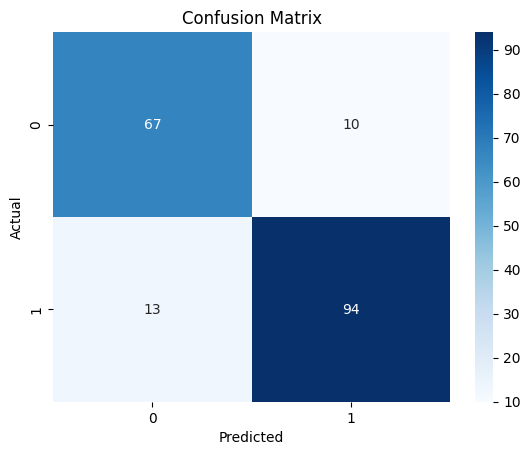

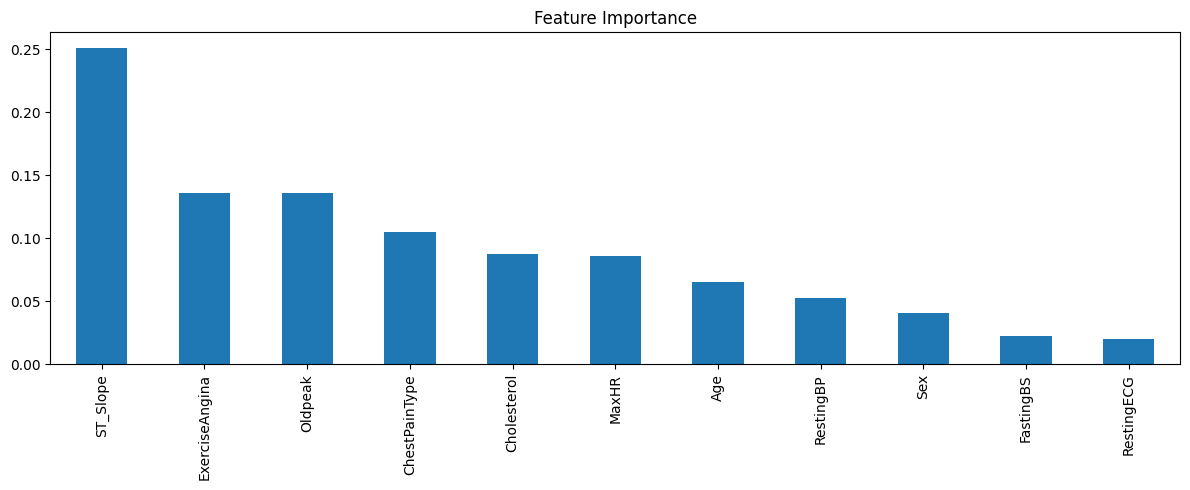

In [28]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Feature importance
feat_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feat_importance.plot(kind='bar', figsize=(12,5), title='Feature Importance')
plt.tight_layout()
plt.show()

12. Save everything

In [29]:
import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(model,          'models/heart_model.pkl')
joblib.dump(scaler,         'models/scaler.pkl')
joblib.dump(num_imputer,    'models/num_imputer.pkl')
joblib.dump(cat_imputer,    'models/cat_imputer.pkl')
joblib.dump(label_encoders, 'models/label_encoders.pkl')

print("All 5 files saved! ✅")

All 5 files saved! ✅
